## Initialization

In [2]:
import os
import torch
import numpy as np
import pandas as pd
import logging
import scipy.io as sio
from scipy.stats import pearsonr
from tqdm import tqdm
import datetime
import shutil
import NPI


In [ ]:
# ================= 配置参数 =================
TOTAL_RUNS = 5          
THRES = 0.6             
ROI_num = 400           
using_steps = 3         
total_subs = 177
batch_size = 50
train_set_proportion = 0.8
num_epochs = 100        # 假设训练轮数

# 目录初始化
RES_BASE_DIR = r"F:\NPI_result_2_7"
TRAIN_BASE = os.path.join(RES_BASE_DIR, "train_ANN")
BEST_EC_DIR = os.path.join(RES_BASE_DIR, "Best_EC_Results")
os.makedirs(BEST_EC_DIR, exist_ok=True)
#
#
#

# 日志配置
log_path = os.path.join(RES_BASE_DIR, f"NPI_Training_{datetime.datetime.now().strftime('%Y%m%d_%H%M')}.log")
logging.basicConfig(level=logging.INFO, format='%(message)s',
                    handlers=[logging.FileHandler(log_path, encoding='utf-8'), logging.StreamHandler()])



### Load data 

In [5]:

# ================= 数据加载 =================
data_root = r"F:\EOS_TD_data"
file_name = 'data_400_208_177.mat'
full_path = os.path.join(data_root, file_name)

logging.info(f"Loading data from: {full_path}")
mat_data = sio.loadmat(full_path) 
all_subjects_data = mat_data['ROI400'].transpose(2, 1, 0) # (Subs, Time, ROIs)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Loading data from: F:\EOS_TD_data\data_400_208_177.mat


## 第一阶段：5轮循环训练
训练5轮，把模型参数分别保存在 train_ANN/run_1~5
如果已经存在，跳过。

In [4]:
logging.info("\n" + "="*30 + " GLOBAL HYPERPARAMETERS " + "="*30)
logging.info(f" - ROI Count: {ROI_num}")
logging.info(f" - Using Steps: {using_steps}")
logging.info(f" - Batch Size: {batch_size}")
logging.info(f" - Device: {device}")
logging.info(f" - Threshold (r): {THRES}")
logging.info("="*84 + "\n")
# ================= 第一阶段：5轮循环训练 =================
for run_idx in range(1, TOTAL_RUNS + 1):
    run_dir = os.path.join(TRAIN_BASE, f"run_{run_idx}")
    os.makedirs(run_dir, exist_ok=True)
    
    logging.info(f"\n>>>> [RUN {run_idx}/{TOTAL_RUNS}] STARTING <<<<")
    
    for sub_idx in range(total_subs):
        display_id = sub_idx + 1
        model_path = os.path.join(run_dir, f"ANN_Sub_{display_id}.pth")
        
        if os.path.exists(model_path):
            logging.info(f"Sub {display_id:03d} | Run {run_idx} | Exists, skipping.")
            continue

        try:
            sub_data = all_subjects_data[sub_idx] 
            inputs, targets = NPI.multi2one(sub_data, steps=using_steps)
            
            ANN = NPI.ANN_MLP(
                input_dim = using_steps * ROI_num, 
                hidden_dim = 2 * ROI_num, 
                latent_dim = int(0.8 * ROI_num), 
                output_dim = ROI_num
            ).to(device)

            ANN, tr_loss, te_loss = NPI.train_NN(
                ANN, inputs, targets, 
                batch_size=batch_size, 
                train_set_proportion=train_set_proportion,
                num_epochs=num_epochs
            )

            torch.save({
                'model_state_dict': ANN.state_dict(),
                'test_loss': te_loss[-1]
            }, model_path)
            
            logging.info(f"Sub {display_id:03d} | Run {run_idx} | OK | TestLoss: {te_loss[-1]:.6f}")
            
            del ANN, inputs, targets
            torch.cuda.empty_cache()
            
        except Exception as e:
            logging.error(f"Sub {display_id:03d} | Run {run_idx} | ERROR: {str(e)}")


>>>> [RUN 1/5] STARTING <<<<
Sub 001 | Run 1 | OK | TestLoss: 0.220074
Sub 002 | Run 1 | OK | TestLoss: 2.671236
Sub 003 | Run 1 | OK | TestLoss: 4.787515
Sub 004 | Run 1 | OK | TestLoss: 3.817907
Sub 005 | Run 1 | OK | TestLoss: 7.043375
Sub 006 | Run 1 | OK | TestLoss: 0.385392
Sub 007 | Run 1 | OK | TestLoss: 2.168212
Sub 008 | Run 1 | OK | TestLoss: 2.362762
Sub 009 | Run 1 | OK | TestLoss: 5.519240
Sub 010 | Run 1 | OK | TestLoss: 3.417481
Sub 011 | Run 1 | OK | TestLoss: 3.766333
Sub 012 | Run 1 | OK | TestLoss: 3.330221
Sub 013 | Run 1 | OK | TestLoss: 5.611403
Sub 014 | Run 1 | OK | TestLoss: 4.485484
Sub 015 | Run 1 | OK | TestLoss: 5.997587
Sub 016 | Run 1 | OK | TestLoss: 5.881511
Sub 017 | Run 1 | OK | TestLoss: 3.348668
Sub 018 | Run 1 | OK | TestLoss: 6.083663
Sub 019 | Run 1 | OK | TestLoss: 5.409831
Sub 020 | Run 1 | OK | TestLoss: 12.780216
Sub 021 | Run 1 | OK | TestLoss: 0.944153
Sub 022 | Run 1 | OK | TestLoss: 4.328862
Sub 023 | Run 1 | OK | TestLoss: 4.978773
Sub

## 第二阶段：评估择优并计算 EC
一共训练5轮，把model_FC & empirical_FC 做相关分析，取最高的r值对应的模型，计算EC，保存在Best_EC_results

In [6]:
# ================= 配置参数 =================
overwrite_EC = False  # 是否覆盖已存在的最优 EC 结果

# ================= 第二阶段：评估择优并计算 EC =================
logging.info("\n" + "="*30 + " SELECTION & EC CALCULATION " + "="*30)
final_report = []

for sub_idx in tqdm(range(total_subs), desc="Selecting Best Model"):
    display_id = sub_idx + 1
    save_path = os.path.join(BEST_EC_DIR, f"EC_Sub_{display_id}.mat")
    
    # --- 覆盖机制检查 ---
    # 如果不覆盖 且 文件已存在：尝试读取旧信息用于报告，然后跳过
    if not overwrite_EC and os.path.exists(save_path):
        try:
            old_data = sio.loadmat(save_path)
            r_val_old = float(old_data['r_value'])
            run_idx_old = int(old_data['run_idx'])
            status = "Passed" if r_val_old >= THRES else "Failed"
            final_report.append([display_id, r_val_old, run_idx_old, status])
            logging.info(f"Sub {display_id:03d} | Existing EC found. Skipping calculation.")
        except Exception:
            logging.warning(f"Sub {display_id:03d} | Found existing EC but failed to read. Recalculating...")
        else:
            continue # 成功读取旧信息，直接处理下一个被试

    # --- 正常的择优与计算流程 ---
    best_r = -1
    best_run = -1
    best_state = None
    
    for run_idx in range(1, TOTAL_RUNS + 1):
        pth_path = os.path.join(TRAIN_BASE, f"run_{run_idx}", f"ANN_Sub_{display_id}.pth")
        if not os.path.exists(pth_path): continue
        
        # 加载模型并计算拟合优度
        ANN = NPI.ANN_MLP(using_steps*ROI_num, 2*ROI_num, int(0.8*ROI_num), ROI_num).to(device)
        try:
            cp = torch.load(pth_path, map_location=device)
            ANN.load_state_dict(cp['model_state_dict'])
            ANN.eval()

            with torch.no_grad():
                model_FC = NPI.model_FC(ANN, node_num=ROI_num, steps=using_steps)
                empirical_FC = NPI.corrcoef(all_subjects_data[sub_idx])
                
                # 健康检查
                if np.isnan(model_FC).any() or np.unique(model_FC).size <= 1:
                    r_val = -1
                else:
                    triu_idx = np.triu_indices(ROI_num, 1)
                    r_val, _ = pearsonr(model_FC[triu_idx], empirical_FC[triu_idx])
                    if np.isnan(r_val): r_val = -1
            
            if r_val > best_r:
                best_r = r_val
                best_run = run_idx
                best_state = cp['model_state_dict']
        except Exception as e:
            logging.error(f"Sub {display_id:03d} | Run {run_idx} | Load Error: {e}")
        
        del ANN
        torch.cuda.empty_cache()

    # --- 最终判定与 EC 计算 ---
    if best_r >= THRES:
        # 重建最优模型以计算 EC
        BEST_ANN = NPI.ANN_MLP(using_steps*ROI_num, 2*ROI_num, int(0.8*ROI_num), ROI_num).to(device)
        BEST_ANN.load_state_dict(best_state)
        
        inputs, targets = NPI.multi2one(all_subjects_data[sub_idx], steps=using_steps)
        NPI_EC = NPI.model_EC(BEST_ANN, inputs, targets, pert_strength=1.0)
        np.fill_diagonal(NPI_EC, 0)
        
        sio.savemat(save_path, {
            'EC': NPI_EC.astype(np.float32),
            'r_value': best_r,
            'run_idx': best_run
        }, do_compression=True)
        
        logging.info(f"Sub {display_id:03d} | Selected Run {best_run} | Max R: {best_r:.4f} | SAVED")
        final_report.append([display_id, best_r, best_run, "Passed"])
    else:
        logging.warning(f"Sub {display_id:03d} | FAILED | Max R: {best_r:.4f}")
        final_report.append([display_id, best_r, best_run, "Failed"])

# 保存最终报表
report_df = pd.DataFrame(final_report, columns=['SubID', 'Best_R', 'From_Run', 'Status'])
report_df.to_csv(os.path.join(RES_BASE_DIR, f"Screening_Report_{datetime.datetime.now().strftime('%Y%m%d')}.csv"), index=False)


============================== SELECTION & EC CALCULATION ==============================
Selecting Best Model:   0%|          | 0/177 [00:00<?, ?it/s]C:\Users\Liang\AppData\Local\Temp\ipykernel_16704\4149386849.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r_val_old = float(old_data['r_value'])
C:\Users\Liang\AppData\Local\Temp\ipykernel_16704\4149386849.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  run_idx_old = int(old_data['run_idx'])
Sub 001 | Existing EC found. Skipping calculation.
Sub 002 | Existing EC found. Skipping calculation.
Sub 003 | Existing EC found. Skipping calculation.
Sub 004 | Existing EC found. Skippin

## 可视化 FC 和 相关图 (optional)
可以查看指定若干个被试的model FC & empirical FC 
以及计算相关性散点图

### 去对角线扁平化function

In [8]:
def flat_without_diagonal(matrix):
    # 使用布尔索引去掉对角线
    mask = ~np.eye(matrix.shape[0], dtype=bool)
    return matrix[mask]

错误：找不到筛选报告，请确保第二阶段代码已运行！


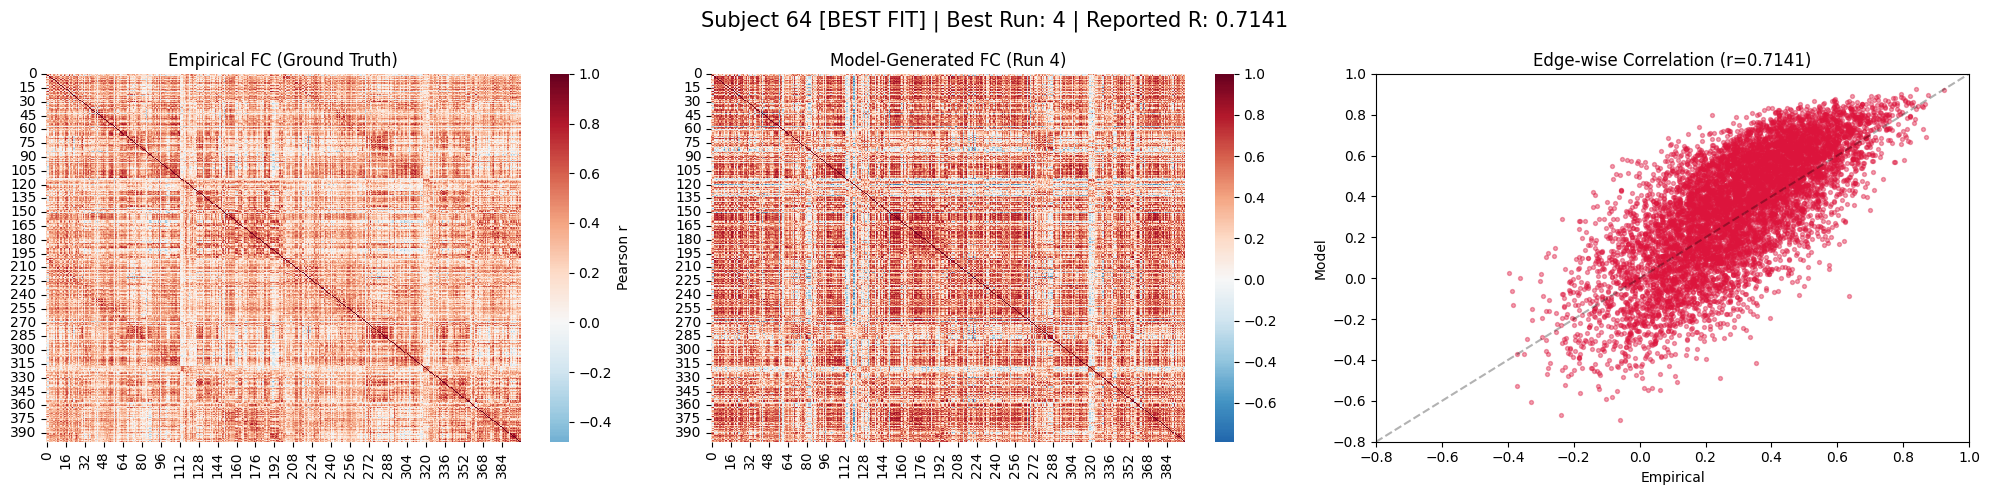

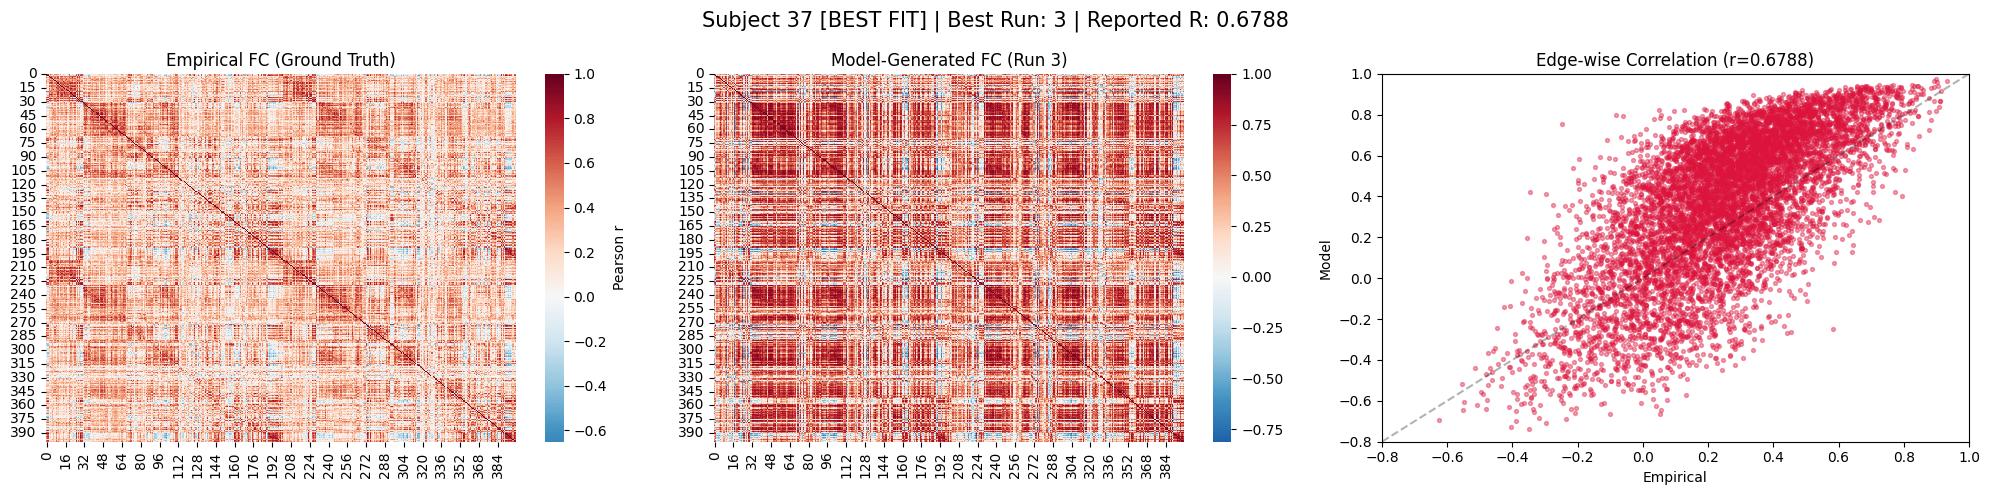

警告：Sub 131 的所有训练均未达标 (最高 r=0.5888)。


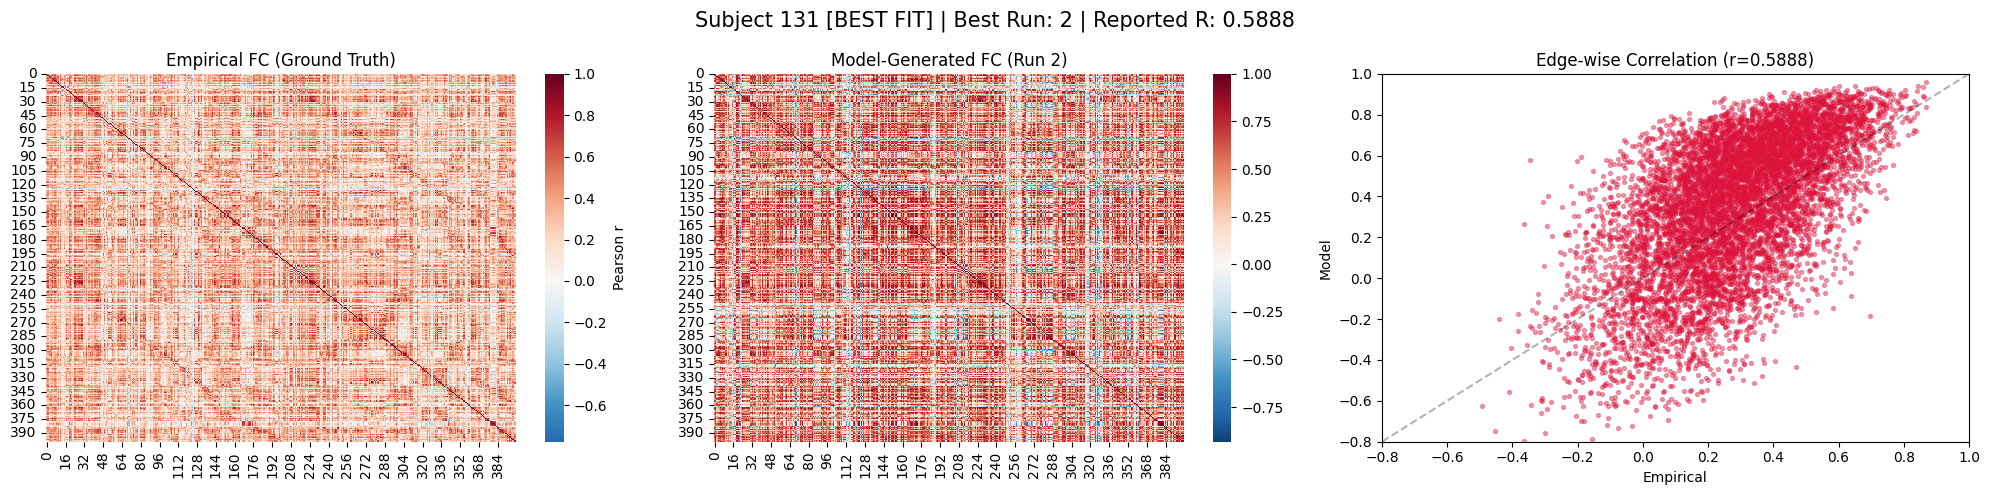

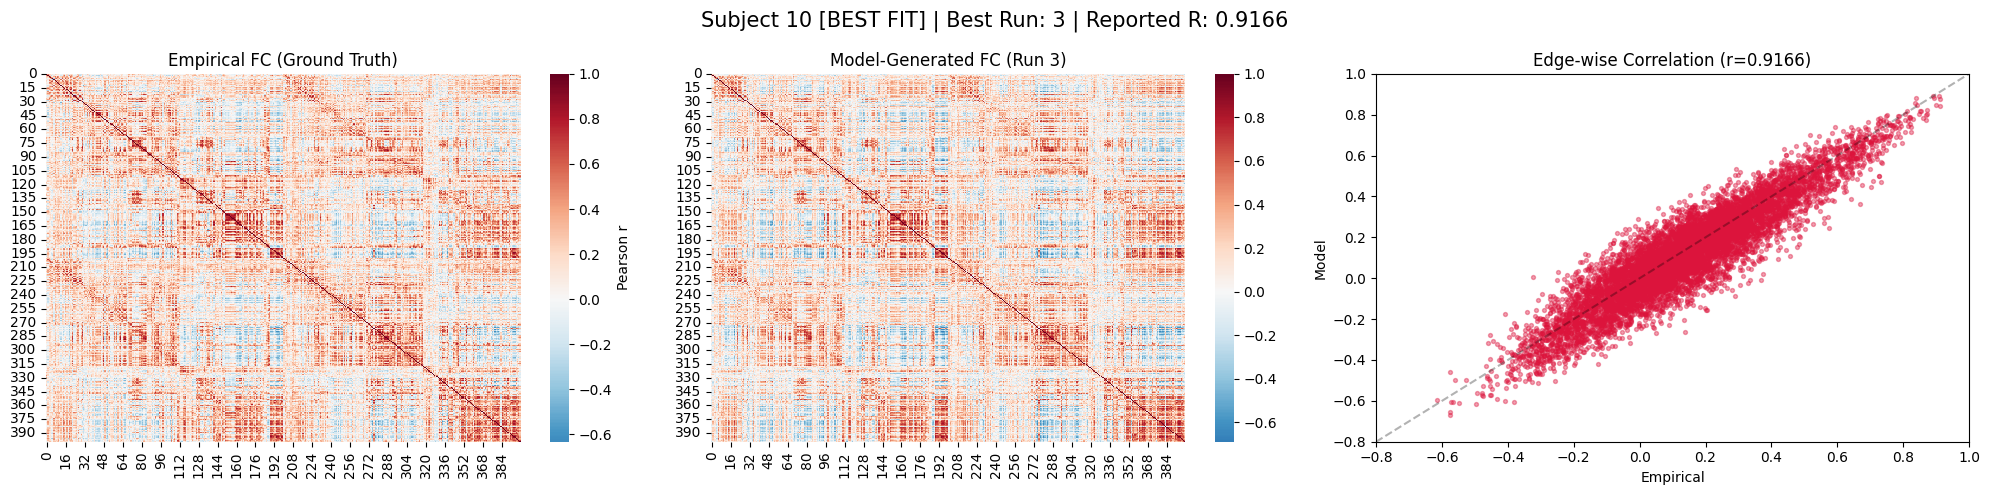

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# --- 1. 加载筛选报告 ---
report_path = os.path.join(RES_BASE_DIR, "Final_Screening_Report.csv")
if not os.path.exists(report_path):
    print("错误：找不到筛选报告，请确保第二阶段代码已运行！")
else:
    report_df = pd.read_csv(report_path)

# --- 2. 想要查看的被试列表 ---
check_list = [64, 37, 131, 10]  # 你感兴趣的 SubID

def visualize_best_fc(sub_id):
    # 从报告中查找该被试的信息
    sub_info = report_df[report_df['SubID'] == sub_id]
    
    if sub_info.empty:
        print(f"Sub {sub_id} 不在报告中。")
        return
    
    best_run = int(sub_info['From_Run'].values[0])
    best_r = sub_info['Best_R'].values[0]
    status = sub_info['Status'].values[0]

    if status == "Failed":
        print(f"警告：Sub {sub_id} 的所有训练均未达标 (最高 r={best_r:.4f})。")
        # 即使失败了，我们也可以看看它长什么样，或者选择 return 跳过

    # 3. 路径准备 (使用查到的 best_run)
    pth_path = os.path.join(TRAIN_BASE, f"run_{best_run}", f"ANN_Sub_{sub_id}.pth")
    
    # --- 加载与绘图逻辑 (同前，略作优化) ---
    ANN = NPI.ANN_MLP(using_steps*ROI_num, 2*ROI_num, int(0.8*ROI_num), ROI_num).to(device)
    cp = torch.load(pth_path, map_location=device)
    ANN.load_state_dict(cp['model_state_dict'])
    ANN.eval()

    with torch.no_grad():
        m_fc = NPI.model_FC(ANN, node_num=ROI_num, steps=using_steps)
        e_fc = NPI.corrcoef(all_subjects_data[sub_id - 1])

    # 4. 计算相关性
    vec_m = flat_without_diagonal(m_fc)
    vec_e = flat_without_diagonal(e_fc)
    r_val, _ = pearsonr(vec_m, vec_e)

    # 5. 可视化
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"Subject {sub_id} [BEST FIT] | Best Run: {best_run} | Reported R: {best_r:.4f}", fontsize=15)

    # 经验 FC
    sns.heatmap(e_fc, ax=axes[0], cmap='RdBu_r', center=0, cbar_kws={'label': 'Pearson r'})
    axes[0].set_title("Empirical FC (Ground Truth)")

    # 模型 FC
    sns.heatmap(m_fc, ax=axes[1], cmap='RdBu_r', center=0)
    axes[1].set_title(f"Model-Generated FC (Run {best_run})")

    # 散点图
    axes[2].scatter(vec_e[::20], vec_m[::20], alpha=0.4, s=8, color='crimson')
    axes[2].plot([-1, 1], [-1, 1], 'k--', alpha=0.3)
    axes[2].set_xlim([-0.8, 1]); axes[2].set_ylim([-0.8, 1])
    axes[2].set_xlabel("Empirical"); axes[2].set_ylabel("Model")
    axes[2].set_title(f"Edge-wise Correlation (r={r_val:.4f})")

    plt.tight_layout()
    plt.show()

# --- 执行循环 ---
for sid in check_list:
    visualize_best_fc(sid)

## EC 7net

In [14]:
import os
import numpy as np
import scipy.io as sio
import pandas as pd
import logging
from tqdm import tqdm

# --- 1. 路径与参数配置 ---
RES_BASE_DIR = r"F:\NPI_result_2_7"
BEST_EC_DIR = os.path.join(RES_BASE_DIR, "Best_EC_Results")
NET_EC_DIR = os.path.join(RES_BASE_DIR, "Net_EC_Results")
REPORT_PATH = os.path.join(RES_BASE_DIR, "Screening_Report.csv")
N7_INDEX_PATH = 'N7index.mat' # 请确保该文件在当前 Python 运行目录下

os.makedirs(NET_EC_DIR, exist_ok=True)

# --- 2. 加载有效被试名单 (从你的筛选报表中读取) ---
if not os.path.exists(REPORT_PATH):
    raise FileNotFoundError(f"找不到筛选报表: {REPORT_PATH}，请先运行择优脚本。")

report_df = pd.read_csv(REPORT_PATH)
# 只处理 Status 为 Passed 的被试
valid_subs_df = report_df[report_df['Status'] == 'Passed']
valid_ids = valid_subs_df['SubID'].tolist()

logging.info(f"开始网络尺度转换。有效被试总数: {len(valid_ids)}")

# --- 3. 加载网络索引 (400*1, 取值 1-7) ---
n7_data = sio.loadmat(N7_INDEX_PATH)
n7_index = n7_data['N7'].flatten() # 确保是一维向量

def roi_to_network_ec(roi_ec, n7_index):
    """
    将 400x400 的 ROI EC 转换为 7x7 的 Network EC (均值法)
    """
    net_ec = np.zeros((7, 7))
    for i in range(1, 8): # 源网络 i
        for j in range(1, 8): # 目标网络 j
            if i == j:
                net_ec[i-1, j-1] = 0
                continue
                
            # 提取 ROI 索引
            source_rois = np.where(n7_index == i)[0]
            target_rois = np.where(n7_index == j)[0]
            
            # 提取子矩阵并取平均
            # sub_matrix 是从网络 i 到网络 j 的所有 ROI 对的连接强度
            sub_matrix = roi_ec[np.ix_(source_rois, target_rois)]
            net_ec[i-1, j-1] = np.mean(sub_matrix)
            
    return net_ec

# --- 4. 批量处理 ---
all_net_ec_list = []

for sub_id in tqdm(valid_ids, desc="Converting to 7-Net"):
    # 文件定位：读取 Best_EC_Results 里的择优结果
    ec_path = os.path.join(BEST_EC_DIR, f"EC_Sub_{sub_id}.mat")
    net_save_path = os.path.join(NET_EC_DIR, f"Net_EC_Sub_{sub_id}.mat")

    if os.path.exists(ec_path):
        try:
            # 读取 ROI EC
            data = sio.loadmat(ec_path)
            roi_ec = data['EC']
            original_r = data['r_value'][0][0] # 兼容 .mat 读取出的 array 格式
            
            # 转换为 7x7
            net_ec = roi_to_network_ec(roi_ec, n7_index)
            
            # 保存 7x7 结果
            sio.savemat(net_save_path, {
                'net_ec': net_ec.astype(np.float32),
                'subject_id': sub_id,
                'original_r': original_r
            }, do_compression=True)
            
            all_net_ec_list.append(net_ec)
            
        except Exception as e:
            logging.error(f"Sub {sub_id} 转换失败: {e}")
    else:
        logging.warning(f"Sub {sub_id} 对应的 EC 文件不存在，请检查 Best_EC_Results 目录。")

# # --- 5. 计算并保存组平均 (Group Average) ---
# if all_net_ec_list:
#     group_avg_net_ec = np.mean(np.array(all_net_ec_list), axis=0)
#     sio.savemat(os.path.join(RES_BASE_DIR, "Group_Average_Net_EC.mat"), {
#         'group_net_ec': group_avg_net_ec
#     })
#     logging.info(f"所有转换完成。组平均网络 EC 已保存至根目录。")

开始网络尺度转换。有效被试总数: 176
Converting to 7-Net: 100%|██████████| 176/176 [00:00<00:00, 191.12it/s]
